# 第306章: 潜在空間の線形補間とSlerp

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] 線形補間（Lerp）と球面線形補間（Slerp）の数式を書けて実装できる
- [ ] なぜ高次元正規分布では球面補間が適切かを幾何学的に説明できる
- [ ] LerpとSlerpの補間品質の違いを実験的に比較できる
- [ ] 補間パスの長さ・密度の概念を理解し、品質との関係を説明できる

## 🎯 前提知識

- ✅ Notebook 300-305（潜在空間の基礎、GAN潜在空間）
- ✅ ベクトルの内積、ノルム、角度の基本

⏱️ **推定学習時間**: 60-90分
📊 **難易度**: ★★★☆☆（中級）
🎓 **カテゴリ**: 理論・実践

---

## 🌟 はじめに

これまで何度か潜在空間での「補間」を使ってきましたが、
実は2つの点を結ぶ方法は**1つではありません**。

```
  線形補間（Lerp）              球面線形補間（Slerp）
  ────────────                  ──────────────────

       z₂                           z₂
      ╱                             ╱
     ╱  直線                      ╱  球面上の
    ╱   経路                    ╱    弧の経路
   ╱                          ╱
  z₁                        z₁

  通過する点のノルムが        通過する点のノルムが
  途中で減少する               一定に保たれる
```

### なぜこの違いが重要なのか？

GANの潜在空間 z ∼ N(0, I) では、**大部分のデータが原点から一定距離の「殻」に集中**します。
線形補間は原点近くを通るため、「データが存在しない領域」を通過してしまいます。

### 📝 この章の構成

1. **Lerpの数式と実装** — 最もシンプルな補間
2. **高次元正規分布の幾何学** — なぜ球面か？
3. **Slerpの数式と実装** — 球面上の最短経路
4. **品質比較** — GANとVAEでLerp vs Slerpを比較
5. **補間パスの分析** — ノルムの変化と品質の関係

In [1]:
# ============================================================
# 環境設定
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import warnings

warnings.filterwarnings('ignore')

def setup_japanese_font():
    japanese_fonts = ['Hiragino Sans', 'Yu Gothic', 'MS Gothic', 'Noto Sans CJK JP', 'IPAexGothic']
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

print(f"Device: {device}")
print("✅ 環境設定完了")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Device: cpu
✅ 環境設定完了


---

## 1. 線形補間（Lerp）

### 📊 数式

2つのベクトル z₁ と z₂ の間の線形補間（Linear Interpolation）：

$$z(\alpha) = (1 - \alpha) \cdot z_1 + \alpha \cdot z_2, \quad \alpha \in [0, 1]$$

- α = 0 のとき z₁
- α = 1 のとき z₂
- α = 0.5 のとき中点

最もシンプルで直感的ですが、高次元では問題があります。

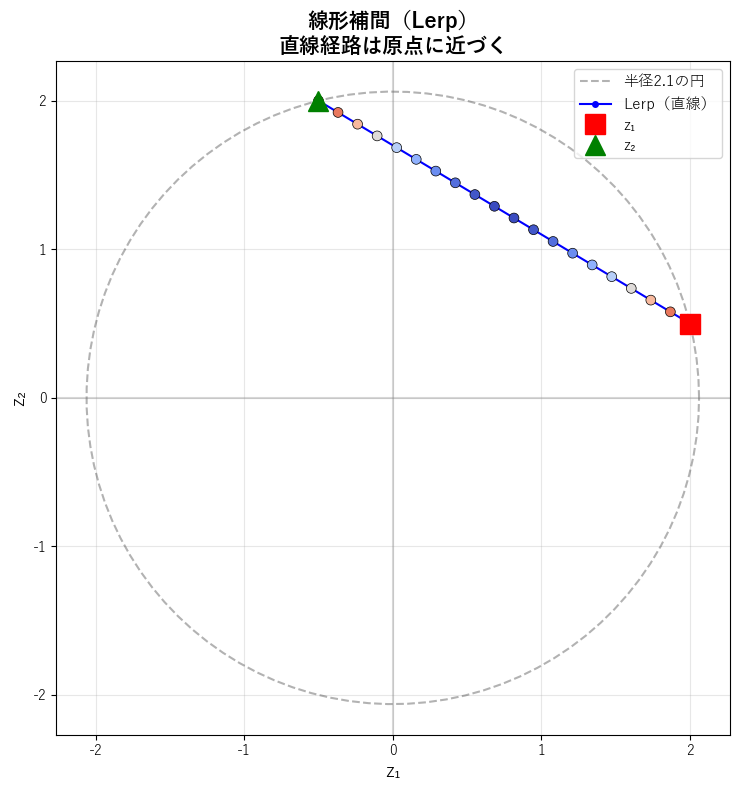

💡 Lerpは「直線」を通る → 途中でノルムが減少する
   z₁のノルム: 2.062
   中点のノルム: 1.458
   z₂のノルム: 2.062


In [2]:
# ============================================================
# Lerp（線形補間）の実装と可視化
# ============================================================

def lerp(z1, z2, alpha):
    """線形補間 (Linear Interpolation)"""
    return (1 - alpha) * z1 + alpha * z2

# 2Dで可視化
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

z1_2d = np.array([2.0, 0.5])
z2_2d = np.array([-0.5, 2.0])

# 補間パス
alphas = np.linspace(0, 1, 20)
lerp_path = np.array([lerp(z1_2d, z2_2d, a) for a in alphas])

# 単位円
theta = np.linspace(0, 2 * np.pi, 100)
r = np.linalg.norm(z1_2d)
ax.plot(r * np.cos(theta), r * np.sin(theta), 'k--', alpha=0.3, label=f'半径{r:.1f}の円')

# Lerpパス
ax.plot(lerp_path[:, 0], lerp_path[:, 1], 'b-o', markersize=4, label='Lerp（直線）')
ax.plot(*z1_2d, 'rs', markersize=15, label='z₁', zorder=5)
ax.plot(*z2_2d, 'g^', markersize=15, label='z₂', zorder=5)

# ノルムの変化を色で表示
norms = np.linalg.norm(lerp_path, axis=1)
ax.scatter(lerp_path[:, 0], lerp_path[:, 1], c=norms, cmap='coolwarm',
           s=50, zorder=4, edgecolors='black', linewidth=0.5)

ax.set_xlabel('z₁', fontsize=14)
ax.set_ylabel('z₂', fontsize=14)
ax.set_title('線形補間（Lerp）\n直線経路は原点に近づく', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', alpha=0.3)
ax.axvline(x=0, color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_306_01_lerp_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Lerpは「直線」を通る → 途中でノルムが減少する")
print(f"   z₁のノルム: {np.linalg.norm(z1_2d):.3f}")
print(f"   中点のノルム: {np.linalg.norm(lerp(z1_2d, z2_2d, 0.5)):.3f}")
print(f"   z₂のノルム: {np.linalg.norm(z2_2d):.3f}")

---

## 2. 高次元正規分布の幾何学

### 🤔 高次元での直感が壊れる瞬間

N次元の標準正規分布 z ∼ N(0, Iₙ) では、驚くべきことに：

> **ほとんどすべてのサンプルが、半径 √N 付近の薄い「殻」に集中する**

| 次元 N | 平均的なノルム E[‖z‖] | ノルムの標準偏差 |
|--------|---------------------|---------------|
| 2 | 1.25 | 0.66 |
| 10 | 3.08 | 0.47 |
| 64 | 7.94 | 0.44 |
| 512 | 22.6 | 0.31 |

次元が高くなるほど「殻」はどんどん薄くなり、ノルムがほぼ一定になります。

### ⚡ Lerpの問題点

線形補間は**殻の内側**（原点近く）を通過するため、
GANのGeneratorがほとんど見たことがない領域を通ることになります。

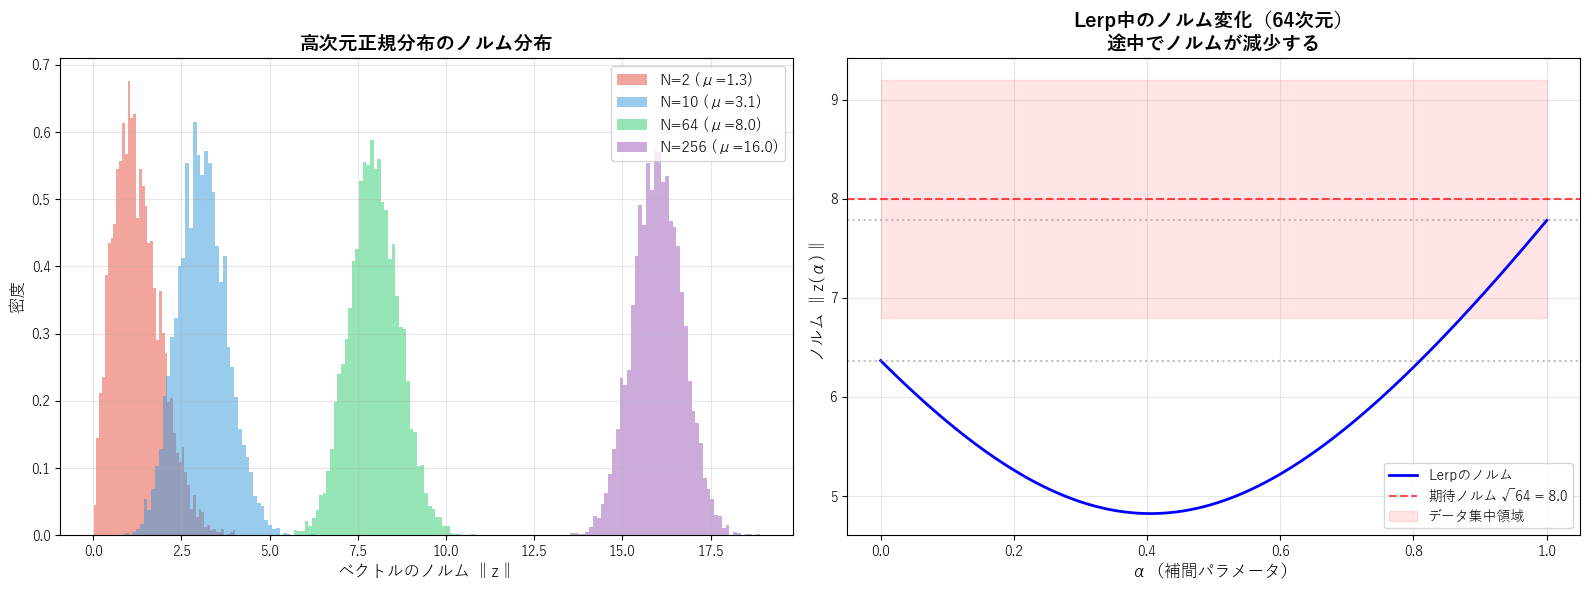

💡 64次元では、ほとんどのサンプルがノルム≈8.0付近に集中
   Lerpは途中でノルムが減少 → データが少ない領域を通過
   これが補間品質の低下を引き起こす


In [3]:
# ============================================================
# 高次元正規分布のノルム分布
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 各次元でのノルム分布
dims = [2, 10, 64, 256]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for dim, color in zip(dims, colors):
    samples = np.random.randn(5000, dim)
    norms = np.linalg.norm(samples, axis=1)
    axes[0].hist(norms, bins=50, alpha=0.5, color=color, density=True,
                label=f'N={dim} (μ={norms.mean():.1f})')

axes[0].set_xlabel('ベクトルのノルム ‖z‖', fontsize=12)
axes[0].set_ylabel('密度', fontsize=12)
axes[0].set_title('高次元正規分布のノルム分布', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右: Lerp中のノルム変化（高次元）
dim = 64
z1 = np.random.randn(dim)
z2 = np.random.randn(dim)
alphas_fine = np.linspace(0, 1, 100)

lerp_norms = [np.linalg.norm(lerp(z1, z2, a)) for a in alphas_fine]
expected_norm = np.sqrt(dim)

axes[1].plot(alphas_fine, lerp_norms, 'b-', linewidth=2, label='Lerpのノルム')
axes[1].axhline(y=expected_norm, color='red', linestyle='--', alpha=0.7,
               label=f'期待ノルム √{dim} = {expected_norm:.1f}')
axes[1].axhline(y=np.linalg.norm(z1), color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(y=np.linalg.norm(z2), color='gray', linestyle=':', alpha=0.5)

axes[1].fill_between(alphas_fine, expected_norm * 0.85, expected_norm * 1.15,
                    alpha=0.1, color='red', label='データ集中領域')
axes[1].set_xlabel('α（補間パラメータ）', fontsize=12)
axes[1].set_ylabel('ノルム ‖z(α)‖', fontsize=12)
axes[1].set_title(f'Lerp中のノルム変化（{dim}次元）\n途中でノルムが減少する',
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_306_02_highdim_norms.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 64次元では、ほとんどのサンプルがノルム≈8.0付近に集中")
print("   Lerpは途中でノルムが減少 → データが少ない領域を通過")
print("   これが補間品質の低下を引き起こす")

---

## 3. 球面線形補間（Slerp）

### 📊 数式

**Slerp (Spherical Linear Interpolation)** は球面上の最短経路（大円弧）に沿った補間です：

$$z(\alpha) = \frac{\sin((1-\alpha)\Omega)}{\sin \Omega} \cdot z_1 + \frac{\sin(\alpha \Omega)}{\sin \Omega} \cdot z_2$$

ここで Ω は z₁ と z₂ の間の角度：

$$\Omega = \arccos\left(\frac{z_1 \cdot z_2}{\|z_1\| \|z_2\|}\right)$$

### Lerpとの違い

| 特性 | Lerp | Slerp |
|------|------|-------|
| 経路 | 直線 | 球面上の弧 |
| ノルム変化 | 途中で減少 | 一定（球面上を移動） |
| 速度 | 一定 | 弧長に比例して一定 |
| 適用場面 | VAE（正則化済み） | GAN（高次元正規分布） |

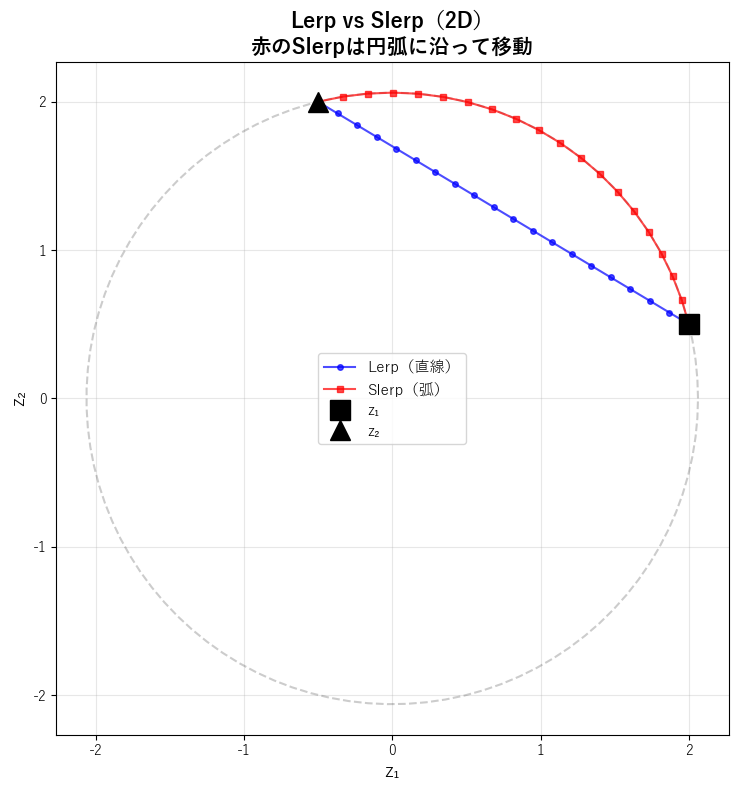

💡 Lerp（青）: 直線 → 原点に近づく
   Slerp（赤）: 弧 → ノルムが一定に保たれる


In [4]:
# ============================================================
# Slerpの実装
# ============================================================

def slerp(z1, z2, alpha):
    """球面線形補間 (Spherical Linear Interpolation)"""
    z1_n = z1 / (np.linalg.norm(z1) + 1e-10)
    z2_n = z2 / (np.linalg.norm(z2) + 1e-10)

    # 2ベクトル間の角度
    dot = np.clip(np.dot(z1_n, z2_n), -1.0, 1.0)
    omega = np.arccos(dot)

    if omega < 1e-10:
        # ほぼ同じ方向 → Lerpにフォールバック
        return lerp(z1, z2, alpha)

    # ノルムも補間（始点と終点のノルムを保持）
    norm1 = np.linalg.norm(z1)
    norm2 = np.linalg.norm(z2)
    interp_norm = (1 - alpha) * norm1 + alpha * norm2

    # 方向の球面補間
    coeff1 = np.sin((1 - alpha) * omega) / np.sin(omega)
    coeff2 = np.sin(alpha * omega) / np.sin(omega)
    direction = coeff1 * z1_n + coeff2 * z2_n

    return direction * interp_norm

# 2Dでの比較
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

z1_2d = np.array([2.0, 0.5])
z2_2d = np.array([-0.5, 2.0])

# 補間パス
alphas = np.linspace(0, 1, 20)
lerp_pts = np.array([lerp(z1_2d, z2_2d, a) for a in alphas])
slerp_pts = np.array([slerp(z1_2d, z2_2d, a) for a in alphas])

# 円
r = np.linalg.norm(z1_2d)
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(r * np.cos(theta), r * np.sin(theta), 'k--', alpha=0.2)

# パスを描画
ax.plot(lerp_pts[:, 0], lerp_pts[:, 1], 'b-o', markersize=4, alpha=0.7, label='Lerp（直線）')
ax.plot(slerp_pts[:, 0], slerp_pts[:, 1], 'r-s', markersize=4, alpha=0.7, label='Slerp（弧）')
ax.plot(*z1_2d, 'ks', markersize=15, zorder=5, label='z₁')
ax.plot(*z2_2d, 'k^', markersize=15, zorder=5, label='z₂')

ax.set_xlabel('z₁', fontsize=14)
ax.set_ylabel('z₂', fontsize=14)
ax.set_title('Lerp vs Slerp（2D）\n赤のSlerpは円弧に沿って移動', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_306_03_lerp_vs_slerp_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Lerp（青）: 直線 → 原点に近づく")
print("   Slerp（赤）: 弧 → ノルムが一定に保たれる")

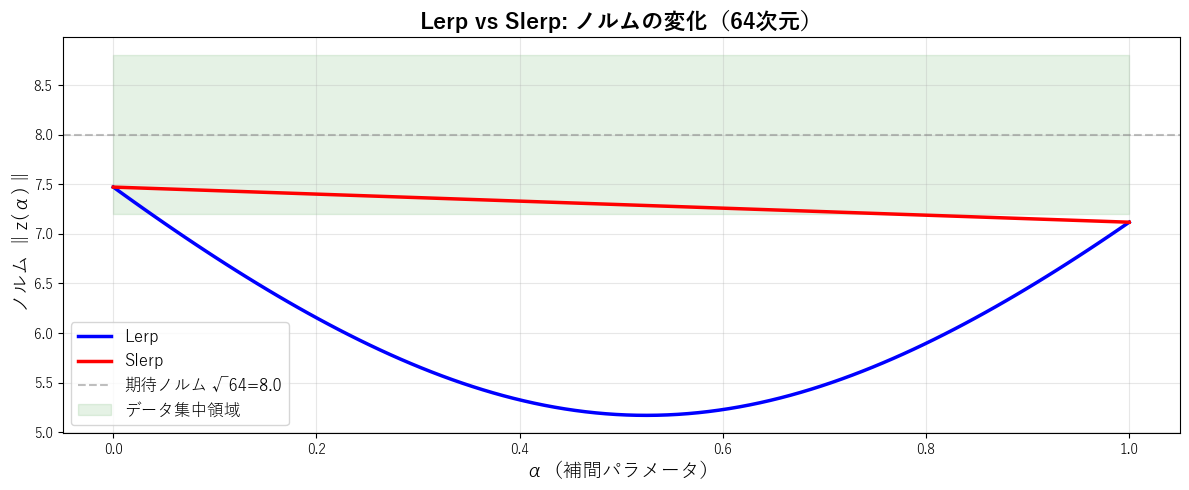

💡 Lerpの中点ノルム: 5.17 (期待値8.00から35.3%乖離)
   Slerpの中点ノルム: 7.29 (期待値からの乖離が小さい)


In [5]:
# ============================================================
# ノルム変化の比較（64次元）
# ============================================================

dim = 64
z1_hd = np.random.randn(dim)
z2_hd = np.random.randn(dim)
alphas_fine = np.linspace(0, 1, 100)

lerp_norms_hd = [np.linalg.norm(lerp(z1_hd, z2_hd, a)) for a in alphas_fine]
slerp_norms_hd = [np.linalg.norm(slerp(z1_hd, z2_hd, a)) for a in alphas_fine]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(alphas_fine, lerp_norms_hd, 'b-', linewidth=2.5, label='Lerp')
ax.plot(alphas_fine, slerp_norms_hd, 'r-', linewidth=2.5, label='Slerp')
ax.axhline(y=np.sqrt(dim), color='gray', linestyle='--', alpha=0.5, label=f'期待ノルム √{dim}={np.sqrt(dim):.1f}')

ax.fill_between(alphas_fine, np.sqrt(dim)*0.9, np.sqrt(dim)*1.1,
               alpha=0.1, color='green', label='データ集中領域')

ax.set_xlabel('α（補間パラメータ）', fontsize=14)
ax.set_ylabel('ノルム ‖z(α)‖', fontsize=14)
ax.set_title(f'Lerp vs Slerp: ノルムの変化（{dim}次元）', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_306_04_norm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💡 Lerpの中点ノルム: {lerp_norms_hd[50]:.2f} (期待値{np.sqrt(dim):.2f}から{abs(lerp_norms_hd[50]-np.sqrt(dim))/np.sqrt(dim)*100:.1f}%乖離)")
print(f"   Slerpの中点ノルム: {slerp_norms_hd[50]:.2f} (期待値からの乖離が小さい)")

---

## 4. 実際のGANでLerp vs Slerpを比較

理論だけでなく、実際に画像生成で品質がどう変わるか確認しましょう。

In [6]:
# ============================================================
# GANの学習
# ============================================================

class Generator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256, 512), nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 784), nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

latent_dim = 64
G = Generator(latent_dim).to(device)
D_net = Discriminator().to(device)

transform_gan = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform_gan)
train_ld = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D_net.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()

print("GAN学習中...")
for epoch in range(2):
    for real, _ in train_ld:
        bs = real.size(0)
        real = real.view(bs, -1).to(device)
        ones = torch.ones(bs, 1).to(device)
        zeros = torch.zeros(bs, 1).to(device)

        z = torch.randn(bs, latent_dim).to(device)
        fake = G(z)
        d_loss = bce(D_net(real), ones) + bce(D_net(fake.detach()), zeros)
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        z = torch.randn(bs, latent_dim).to(device)
        g_loss = bce(D_net(G(z)), ones)
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/30")
print("✅ GAN学習完了")

GAN学習中...
✅ GAN学習完了


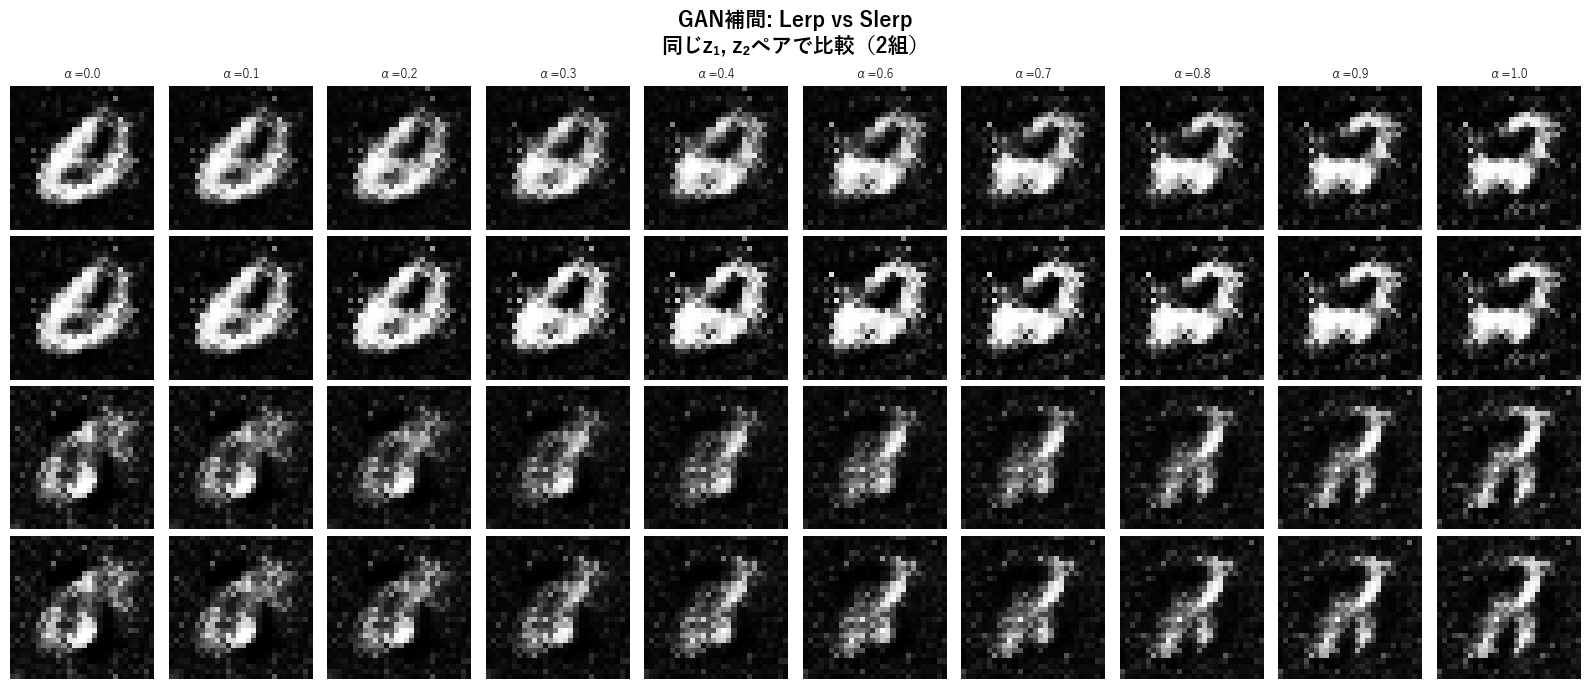

💡 Slerpのほうが途中の画像品質が安定している傾向があるか観察してください
   特にα=0.3〜0.7の中間領域で違いが出やすい


In [7]:
# ============================================================
# Lerp vs Slerp: GAN画像補間の比較
# ============================================================

G.eval()
n_interp = 10
alphas = np.linspace(0, 1, n_interp)

fig, axes = plt.subplots(4, n_interp, figsize=(16, 7))

for pair_idx in range(2):
    z1 = np.random.randn(latent_dim)
    z2 = np.random.randn(latent_dim)

    # Lerp
    row_lerp = pair_idx * 2
    for i, alpha in enumerate(alphas):
        z_int = lerp(z1, z2, alpha)
        z_t = torch.tensor(z_int, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            img = G(z_t).cpu().numpy().reshape(28, 28)
        img = (img + 1) / 2
        axes[row_lerp, i].imshow(img, cmap='gray')
        axes[row_lerp, i].axis('off')
        if i == 0:
            axes[row_lerp, i].set_ylabel('Lerp', fontsize=12, rotation=0, labelpad=35)
        if pair_idx == 0:
            axes[row_lerp, i].set_title(f'α={alpha:.1f}', fontsize=9)

    # Slerp
    row_slerp = pair_idx * 2 + 1
    for i, alpha in enumerate(alphas):
        z_int = slerp(z1, z2, alpha)
        z_t = torch.tensor(z_int, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            img = G(z_t).cpu().numpy().reshape(28, 28)
        img = (img + 1) / 2
        axes[row_slerp, i].imshow(img, cmap='gray')
        axes[row_slerp, i].axis('off')
        if i == 0:
            axes[row_slerp, i].set_ylabel('Slerp', fontsize=12, rotation=0, labelpad=35)

fig.suptitle('GAN補間: Lerp vs Slerp\n同じz₁, z₂ペアで比較（2組）',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_306_05_lerp_vs_slerp_gan.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Slerpのほうが途中の画像品質が安定している傾向があるか観察してください")
print("   特にα=0.3〜0.7の中間領域で違いが出やすい")

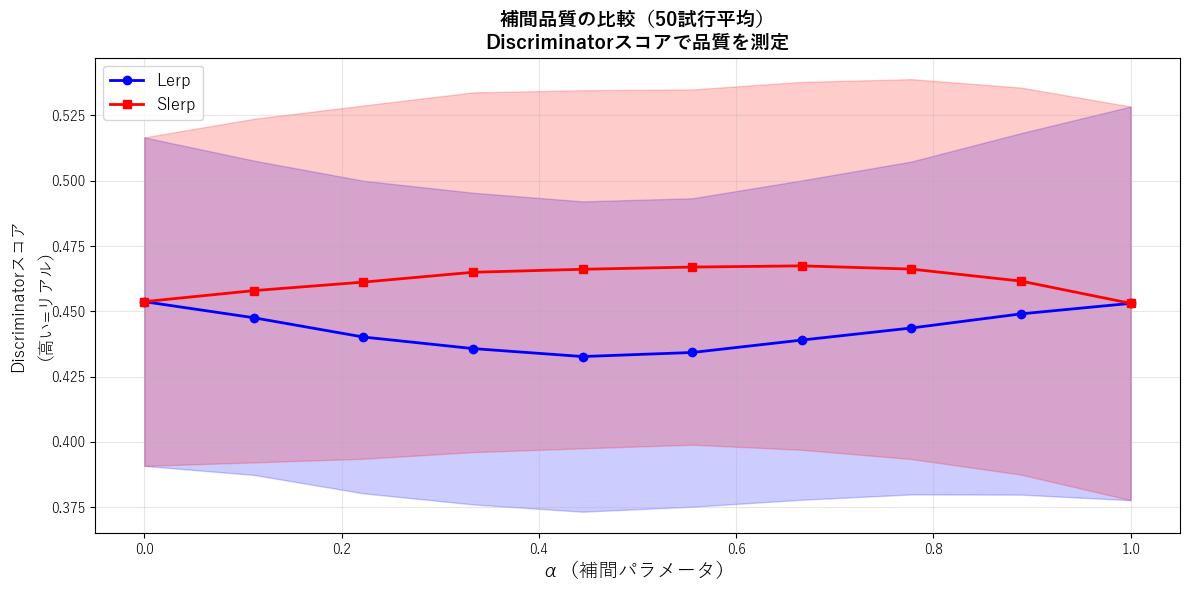

💡 中間点（α=0.5）のDスコア:
   Lerp:  0.4342
   Slerp: 0.4669
   差: +0.0327 (Slerpが良い)


In [8]:
# ============================================================
# 補間品質の定量評価
# Discriminatorのスコアで品質を測定
# ============================================================

n_trials = 50
lerp_scores_all = []
slerp_scores_all = []

D_net.eval()
G.eval()

for _ in range(n_trials):
    z1 = np.random.randn(latent_dim)
    z2 = np.random.randn(latent_dim)

    lerp_scores = []
    slerp_scores = []

    for alpha in alphas:
        with torch.no_grad():
            # Lerp
            z_l = torch.tensor(lerp(z1, z2, alpha), dtype=torch.float32).unsqueeze(0).to(device)
            score_l = D_net(G(z_l)).item()
            lerp_scores.append(score_l)

            # Slerp
            z_s = torch.tensor(slerp(z1, z2, alpha), dtype=torch.float32).unsqueeze(0).to(device)
            score_s = D_net(G(z_s)).item()
            slerp_scores.append(score_s)

    lerp_scores_all.append(lerp_scores)
    slerp_scores_all.append(slerp_scores)

lerp_scores_mean = np.mean(lerp_scores_all, axis=0)
slerp_scores_mean = np.mean(slerp_scores_all, axis=0)
lerp_scores_std = np.std(lerp_scores_all, axis=0)
slerp_scores_std = np.std(slerp_scores_all, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(alphas, lerp_scores_mean, 'b-o', linewidth=2, label='Lerp', markersize=6)
ax.fill_between(alphas, lerp_scores_mean - lerp_scores_std,
               lerp_scores_mean + lerp_scores_std, alpha=0.2, color='blue')

ax.plot(alphas, slerp_scores_mean, 'r-s', linewidth=2, label='Slerp', markersize=6)
ax.fill_between(alphas, slerp_scores_mean - slerp_scores_std,
               slerp_scores_mean + slerp_scores_std, alpha=0.2, color='red')

ax.set_xlabel('α（補間パラメータ）', fontsize=14)
ax.set_ylabel('Discriminatorスコア\n（高い=リアル）', fontsize=12)
ax.set_title(f'補間品質の比較（{n_trials}試行平均）\nDiscriminatorスコアで品質を測定',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_306_06_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

mid_lerp = lerp_scores_mean[len(alphas)//2]
mid_slerp = slerp_scores_mean[len(alphas)//2]
print(f"💡 中間点（α=0.5）のDスコア:")
print(f"   Lerp:  {mid_lerp:.4f}")
print(f"   Slerp: {mid_slerp:.4f}")
print(f"   差: {mid_slerp - mid_lerp:+.4f} ({'Slerpが良い' if mid_slerp > mid_lerp else 'Lerpが良い'})")

---

## まとめ

### 🎯 このノートブックで学んだこと

**Lerp（線形補間）**
- ✓ z(α) = (1-α)z₁ + αz₂ — 最もシンプル
- ✓ 高次元ではノルムが減少し、データが少ない領域を通過する問題

**高次元の幾何学**
- ✓ 高次元正規分布のサンプルは √N 付近の「殻」に集中
- ✓ 次元が高いほど殻は薄くなる

**Slerp（球面線形補間）**
- ✓ 球面上の弧に沿って補間 — ノルムが一定に保たれる
- ✓ GANの潜在空間で特に有効（z ∼ N(0,I) のため）

**実践的ガイドライン**
- ✓ GAN → Slerpを使う（高次元正規分布）
- ✓ VAE → Lerpでも概ね問題ない（KL正則化のため）
- ✓ 品質が気になる場合は常にSlerpが安全な選択

### 📊 チートシート

| 手法 | 数式 | 適用場面 |
|------|------|---------|
| Lerp | (1-α)z₁ + αz₂ | VAE、低次元 |
| Slerp | sin((1-α)Ω)/sinΩ · z₁ + sin(αΩ)/sinΩ · z₂ | GAN、高次元正規分布 |

### ✅ 学習チェックリスト

- [ ] Lerpの問題点を高次元の観点から説明できるか？
- [ ] Slerpの数式を書けるか？
- [ ] GANでSlerpが推奨される理由を説明できるか？

---

**次のステップ**: ノートブック307「意味ベクトルと属性編集」で、InterFaceGANを使った属性方向の発見と精密な画像編集を学びます！

---

## 🎓 自己評価クイズ

### Q1: 64次元の正規分布からサンプリングしたベクトルのノルムは、おおよそいくつになるか？

<details>
<summary>💡 答えを見る</summary>

**答え**: おおよそ √64 = 8.0

高次元正規分布では、サンプルのノルムは √N に集中します。次元が高いほどこの集中は鋭くなります。

</details>

---

### Q2: LerpがGANの潜在空間で問題を起こす原因は？

<details>
<summary>💡 答えを見る</summary>

**答え**: ノルムが小さい領域（原点付近）を通過するため、Generatorがほとんど学習していない領域の画像を生成してしまう

GANのGeneratorは z ∼ N(0,I) のサンプル（ノルム≈√N）で学習するため、ノルムが小さすぎる入力に対しては不自然な画像を出力しやすい。

</details>

---

### Q3: VAEではなぜLerpでも比較的うまくいくのか？

<details>
<summary>💡 答えを見る</summary>

**答え**: KL正則化により潜在空間がN(0,I)に近い連続的な構造を持つため、原点付近にもデータが存在する

VAEのKL項は潜在空間全体をN(0,I)に近づけるため、ノルムが小さい領域にもデータが「押し込まれて」おり、Lerpで通過する経路上にも意味のある潜在コードが存在する。

</details>